# ============================================================
# Analyse Exploratoire et Justification du MDP
# ============================================================

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement du dataset
df = pd.read_csv('../data/retail_store_inventory.csv')

# Affichage des premieres lignes
print("Shape du dataset :", df.shape)
print("\nPremieres lignes :")
df.head()

Shape du dataset : (73100, 15)

Premieres lignes :


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [37]:
# Informations generales sur le dataset
print("Colonnes :")
print(df.columns.tolist())

Colonnes :
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [38]:
print("\nTypes des colonnes :")
print(df.dtypes)


Types des colonnes :
Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition         str
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality               str
dtype: object


In [39]:
print("\nValeurs manquantes :")
print(df.isnull().sum())


Valeurs manquantes :
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [40]:
# Statistiques des colonnes numeriques importantes
colonnes_importantes = [
    'Inventory Level',
    'Units Sold',
    'Units Ordered',
    'Demand Forecast',
    'Price'
]

df[colonnes_importantes].describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108
std,129.949514,108.919406,52.277448,109.254076,26.021945
min,50.000000,0.000000,20.000000,-9.990000,10.000000
25%,162.000000,49.000000,65.000000,53.670000,32.650000
50%,273.000000,107.000000,110.000000,113.015000,55.050000
75%,387.000000,203.000000,155.000000,208.052500,77.860000
max,500.000000,499.000000,200.000000,518.550000,100.000000


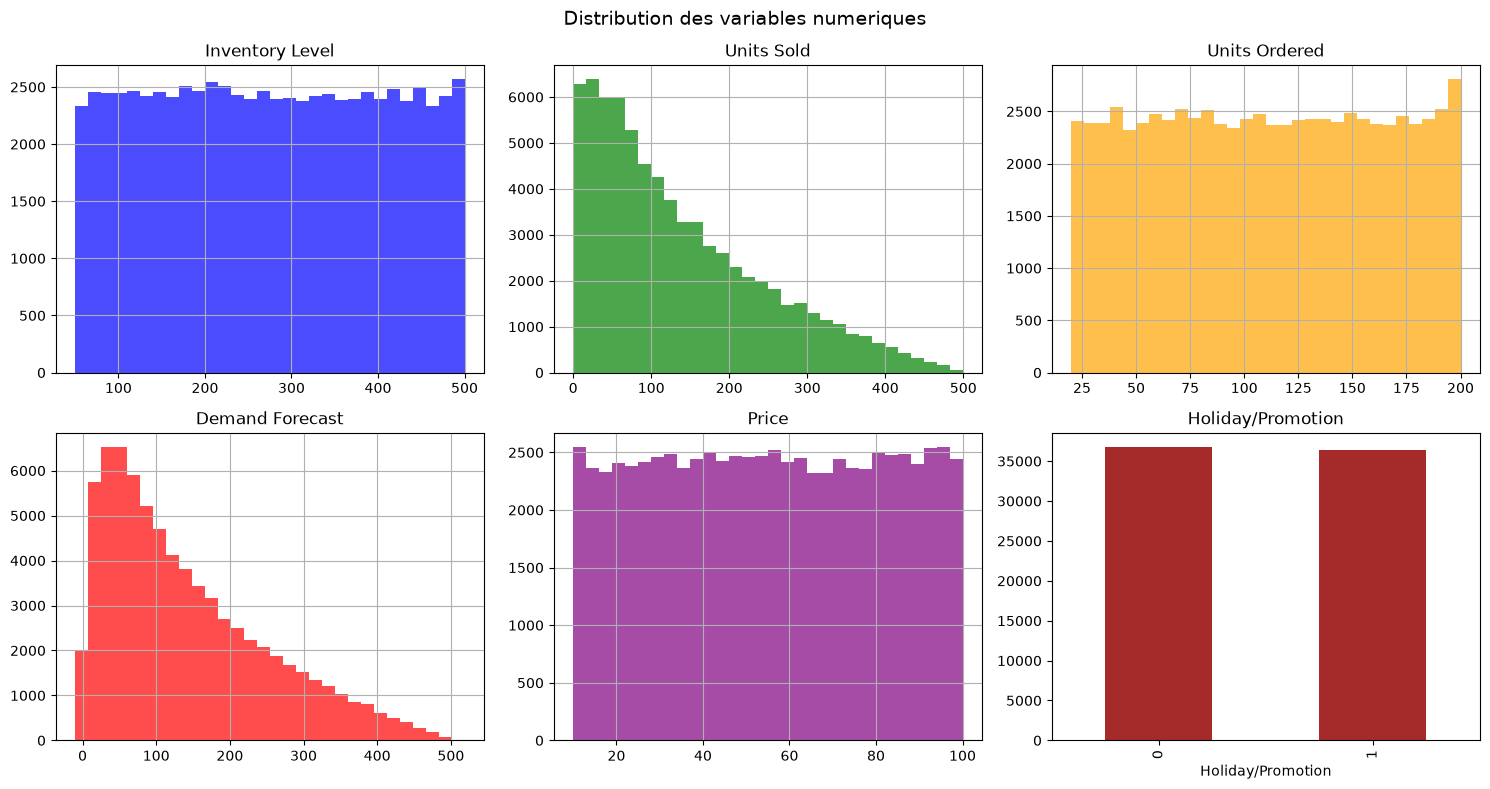

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution des variables numeriques', fontsize=14)

df['Inventory Level'].hist(ax=axes[0,0], bins=30, color='blue', alpha=0.7)
axes[0,0].set_title('Inventory Level')

df['Units Sold'].hist(ax=axes[0,1], bins=30, color='green', alpha=0.7)
axes[0,1].set_title('Units Sold')

df['Units Ordered'].hist(ax=axes[0,2], bins=30, color='orange', alpha=0.7)
axes[0,2].set_title('Units Ordered')

df['Demand Forecast'].hist(ax=axes[1,0], bins=30, color='red', alpha=0.7)
axes[1,0].set_title('Demand Forecast')

df['Price'].hist(ax=axes[1,1], bins=30, color='purple', alpha=0.7)
axes[1,1].set_title('Price')

df['Holiday/Promotion'].value_counts().plot(kind='bar', ax=axes[1,2], color='brown')
axes[1,2].set_title('Holiday/Promotion')

plt.tight_layout()
plt.savefig('../results/plots/distribution.png')
plt.show()

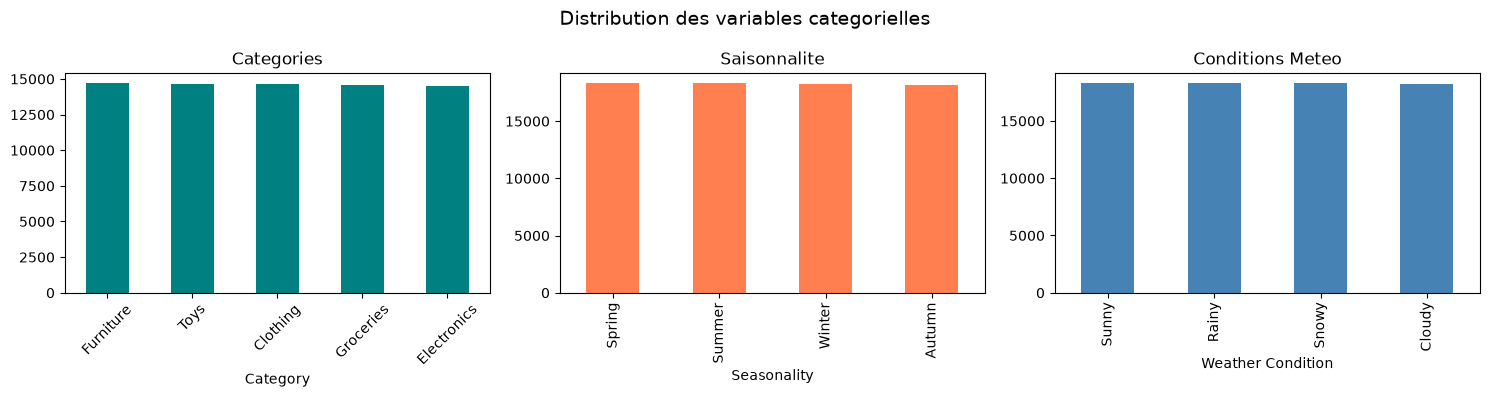

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution des variables categorielles', fontsize=14)

df['Category'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Categories')
axes[0].tick_params(axis='x', rotation=45)

df['Seasonality'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Saisonnalite')

df['Weather Condition'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Conditions Meteo')

plt.tight_layout()
plt.savefig('../results/plots/categories.png')
plt.show()

Le dataset contient 73 100 observations et 15 colonnes sans aucune valeur manquante.

Les variables numeriques cles varient comme suit :
- Inventory Level : entre 50 et 500 unites
- Units Sold : entre 0 et 499 unites
- Units Ordered : entre 20 et 200 unites
- Price : entre 10 et 100 euros

Les variables categorielles sont parfaitement equilibrees entre les 5 categories de produits, les 4 saisons et les 4 conditions meteo.

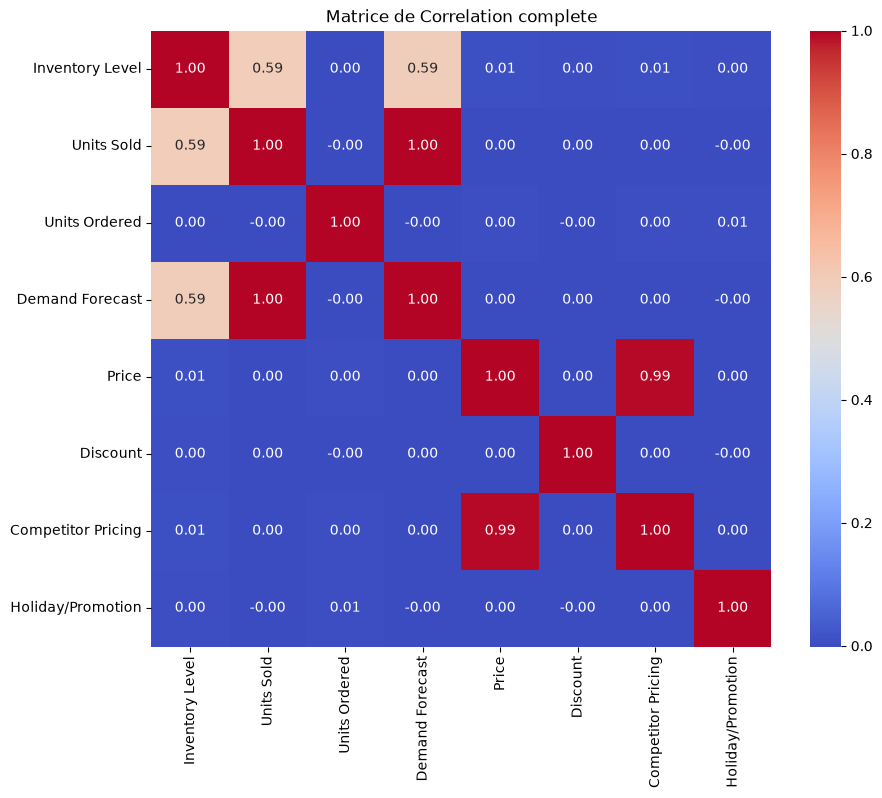

Correlations avec Units Sold :
Units Sold            1.000000
Demand Forecast       0.996853
Inventory Level       0.589995
Discount              0.002576
Competitor Pricing    0.001259
Price                 0.001082
Holiday/Promotion    -0.000374
Units Ordered        -0.000930
Name: Units Sold, dtype: float64


In [43]:
# Etude de toutes les variables numeriques
variables_numeriques = [
    'Inventory Level',
    'Units Sold',
    'Units Ordered',
    'Demand Forecast',
    'Price',
    'Discount',
    'Competitor Pricing',
    'Holiday/Promotion'
]

correlation_complete = df[variables_numeriques].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_complete, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Correlation complete')
plt.savefig('../results/plots/correlation_complete.png')
plt.show()

print("Correlations avec Units Sold :")
print(correlation_complete['Units Sold'].sort_values(ascending=False))

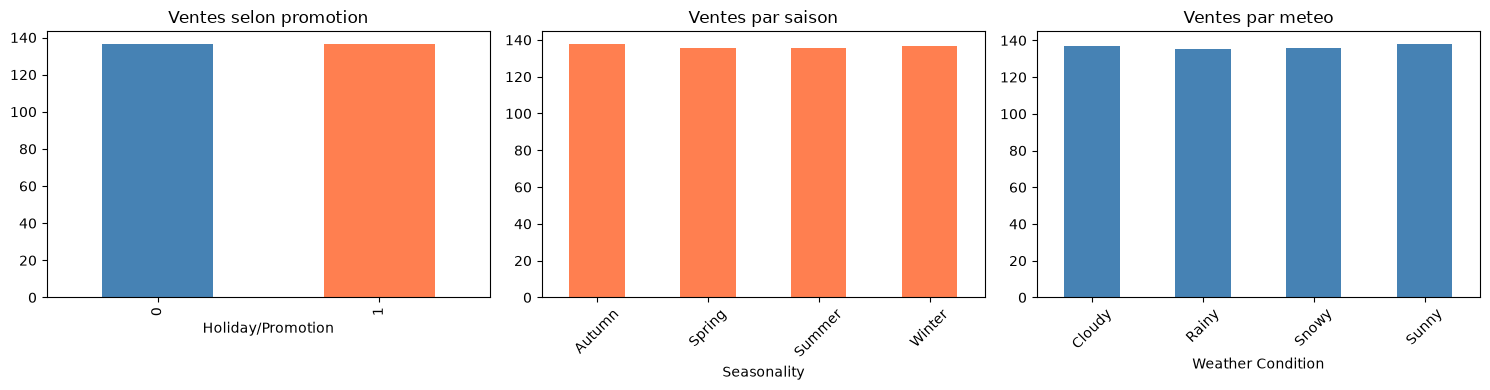

Ventes par promotion :
Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64

Ventes par saison :
Seasonality
Autumn    137.782444
Spring    135.826828
Summer    135.428298
Winter    136.830790
Name: Units Sold, dtype: float64

Ventes par meteo :
Weather Condition
Cloudy    136.758324
Rainy     135.160028
Snowy     135.911559
Sunny     138.028650
Name: Units Sold, dtype: float64


In [44]:
# Impact des variables categorielles sur les ventes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('Holiday/Promotion')['Units Sold'].mean().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral']
)
axes[0].set_title('Ventes selon promotion')

df.groupby('Seasonality')['Units Sold'].mean().plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title('Ventes par saison')
axes[1].tick_params(axis='x', rotation=45)

df.groupby('Weather Condition')['Units Sold'].mean().plot(
    kind='bar', ax=axes[2], color='steelblue'
)
axes[2].set_title('Ventes par meteo')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/plots/impact_categorielles.png')
plt.show()

print("Ventes par promotion :")
print(df.groupby('Holiday/Promotion')['Units Sold'].mean())
print("\nVentes par saison :")
print(df.groupby('Seasonality')['Units Sold'].mean())
print("\nVentes par meteo :")
print(df.groupby('Weather Condition')['Units Sold'].mean())

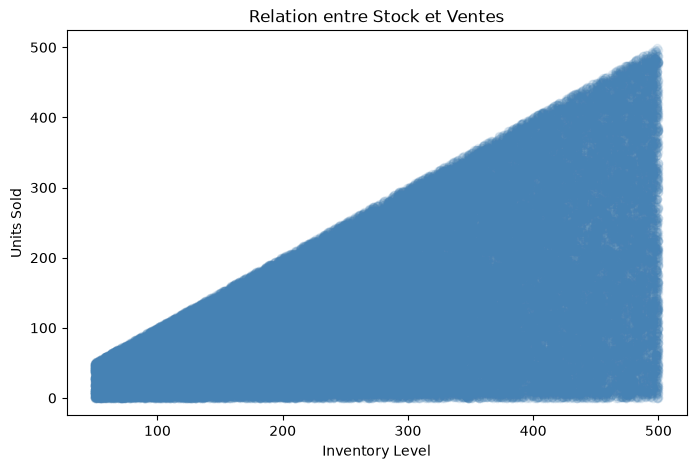

Correlation Stock/Ventes : 0.59
Correlation Prevision/Ventes : 1.00


In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Inventory Level'],
    df['Units Sold'],
    alpha=0.1,
    color='steelblue'
)
plt.xlabel('Inventory Level')
plt.ylabel('Units Sold')
plt.title('Relation entre Stock et Ventes')
plt.savefig('../results/plots/stock_vs_ventes.png')
plt.show()

print(f"Correlation Stock/Ventes : {df['Inventory Level'].corr(df['Units Sold']):.2f}")
print(f"Correlation Prevision/Ventes : {df['Demand Forecast'].corr(df['Units Sold']):.2f}")

Apres l analyse exploratoire deux variables ont montre une relation suffisamment informative avec les ventes pour etre retenues comme etats dans cette premiere version de l environnement :
- Demand Forecast : correlation de 0.99
- Inventory Level : correlation de 0.59

Les autres variables ont presente une faible contribution dans les analyses exploratoires et n ont pas ete retenues.

Le graphique Stock vs Ventes confirme une contrainte physique fondamentale : on ne peut pas vendre plus que le stock disponible.

Analyse de Units Ordered :
count    73100.000000
mean       110.004473
std         52.277448
min         20.000000
25%         65.000000
50%        110.000000
75%        155.000000
max        200.000000
Name: Units Ordered, dtype: float64


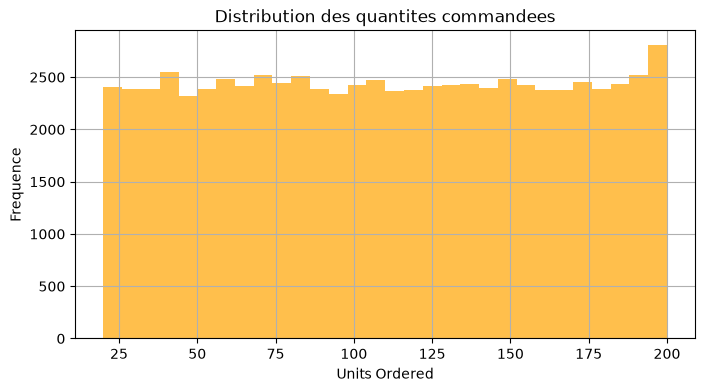

In [46]:
print("Analyse de Units Ordered :")
print(df['Units Ordered'].describe())

plt.figure(figsize=(8, 4))
df['Units Ordered'].hist(bins=30, color='orange', alpha=0.7)
plt.xlabel('Units Ordered')
plt.ylabel('Frequence')
plt.title('Distribution des quantites commandees')
plt.savefig('../results/plots/actions_distribution.png')
plt.show()

La distribution des commandes est uniforme entre 20 et 200 unites sans paliers fixes.

Cela justifie une action continue entre 0 et 200 unites.

L'algorithme DDPG est donc plus adapte que DQN car il gere les espaces d'action continus.

Nombre de ruptures : 369
Pourcentage : 0.5%


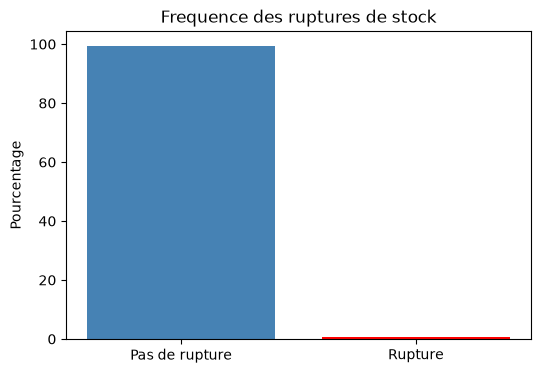

In [47]:
# Une rupture se produit quand la demande depasse le stock
df['rupture'] = (df['Units Sold'] >= df['Inventory Level']).astype(int)
ruptures_pct = df['rupture'].mean() * 100

print(f"Nombre de ruptures : {df['rupture'].sum()}")
print(f"Pourcentage : {ruptures_pct:.1f}%")

plt.figure(figsize=(6, 4))
plt.bar(
    ['Pas de rupture', 'Rupture'],
    [100 - ruptures_pct, ruptures_pct],
    color=['steelblue', 'red']
)
plt.ylabel('Pourcentage')
plt.title('Frequence des ruptures de stock')
plt.savefig('../results/plots/ruptures.png')
plt.show()

Stock restant apres vente :
count    73100.000000
mean       138.005007
std        109.766664
min          0.000000
25%         49.000000
50%        109.000000
75%        205.000000
max        500.000000
Name: stock_restant, dtype: float64


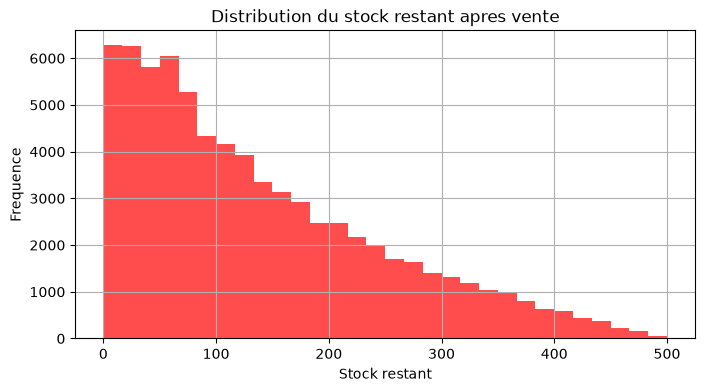

In [48]:
df['stock_restant'] = (df['Inventory Level'] - df['Units Sold']).clip(lower=0)

print("Stock restant apres vente :")
print(df['stock_restant'].describe())

plt.figure(figsize=(8, 4))
df['stock_restant'].hist(bins=30, color='red', alpha=0.7)
plt.xlabel('Stock restant')
plt.ylabel('Frequence')
plt.title('Distribution du stock restant apres vente')
plt.savefig('../results/plots/stock_restant.png')
plt.show()

In [49]:
# cp justifie par le dataset
# si pas de stock on perd la vente
cp = df['Price']

# ch justifie par la litterature
# Newsvendor Problem (Oroojlooyjadid et al. 2017)
# contrainte : ch < cp toujours
# on fixe ch = 20% de cp
ch = cp * 0.20

print(f"cp moyen : {cp.mean():.2f} euros")
print(f"ch moyen : {ch.mean():.2f} euros")
print(f"Ratio cp/ch : {(cp/ch).mean():.1f}")
print(f"Contrainte ch < cp : {(ch < cp).all()}")

cp moyen : 55.14 euros
ch moyen : 11.03 euros
Ratio cp/ch : 5.0
Contrainte ch < cp : True


Les ruptures de stock sont quasi inexistantes (moins de 1%) mais le stock restant moyen est de 138 unites.
Le vrai probleme est le surplus de stock.

La fonction de recompense est basee sur le Newsvendor Problem :
- R = Price x min(d, s) - ch x max(s-d, 0) - cp x max(d-s, 0)
- cp = Price car une rupture entraine une perte directe du prix de vente.
- ch = 20% de cp en respectant la contrainte ch < cp.

Source : arxiv.org/pdf/1607.02177

In [50]:
df['Date'] = pd.to_datetime(df['Date'])

date_min = df['Date'].min()
date_max = df['Date'].max()
duree_totale = (date_max - date_min).days

print(f"Date debut  : {date_min.date()}")
print(f"Date fin    : {date_max.date()}")
print(f"Duree totale : {duree_totale} jours")
print(f"Soit environ : {duree_totale/365:.1f} ans")

Date debut  : 2022-01-01
Date fin    : 2024-01-01
Duree totale : 730 jours
Soit environ : 2.0 ans


In [51]:
# Verification que 365 jours couvre toutes les saisons
saisons_par_annee = df[df['Date'].dt.year == 2022]['Seasonality'].unique()
print("Saisons dans une annee :")
print(saisons_par_annee)
print(f"\n365 jours couvre {len(saisons_par_annee)} saisons")

Saisons dans une annee :
<StringArray>
['Autumn', 'Summer', 'Winter', 'Spring']
Length: 4, dtype: str

365 jours couvre 4 saisons


Le dataset couvre 730 jours soit 2 ans.

Un episode de 365 jours represente un cycle annuel complet qui couvre les 4 saisons disponibles dans le dataset.

Cela permet a l'agent d apprendre a gerer toutes les variations de demande sur une annee complete.

## Conclusion du MDP

| Composante | Valeur | Justification |
|------------|--------|---------------|
| **Etats** | Inventory Level [50, 500] et Demand Forecast [0, 519] | Seules variables avec correlation significative avec les ventes (0.59 et 0.99) |
| **Actions** | Continue entre 0 et 200 | Distribution uniforme de Units Ordered sans paliers fixes → DDPG |
| **Recompense** | R = Price x min(d,s) - ch x max(s-d,0) - cp x max(d-s,0) | Newsvendor Problem (arxiv.org/pdf/1607.02177) |
| **cp** | Price du dataset | Une rupture entraine une perte directe du prix de vente |
| **ch** | 20% de Price | Contrainte ch < cp du Newsvendor Problem |
| **Fin d'episode** | 365 jours | Couvre les 4 saisons du dataset |
| **Algorithme** | DDPG | Action continue entre 0 et 200 |

In [53]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

In [56]:
class InventoryEnv(gym.Env):
    
    def __init__(self, df, episode_length=365):
        super().__init__()
        self.df             = df.reset_index(drop=True)
        self.episode_length = episode_length
        self.cp             = self.df['Price'].values
        self.ch             = self.cp * 0.20
        self.observation_space = spaces.Box(
            low   = np.array([50,  -10]),
            high  = np.array([500,  519]),
            dtype = np.float32
        )
        self.action_space = spaces.Box(
            low   = np.array([0]),
            high  = np.array([200]),
            dtype = np.float32
        )
        self.current_step = 0

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.df.iloc[self.current_step]
        return np.array([
            row['Inventory Level'],
            row['Demand Forecast']
        ], dtype=np.float32)

    def step(self, action):
        action           = float(action[0])
        row              = self.df.iloc[self.current_step]
        stock            = row['Inventory Level']
        demande          = row['Units Sold']
        stock_disponible = stock + action
        ventes           = min(stock_disponible, demande)
        stock_restant    = stock_disponible - ventes
        revenu           = row['Price'] * ventes
        cout_stockage    = self.ch[self.current_step] * max(stock_restant, 0)
        cout_rupture     = self.cp[self.current_step] * max(demande - stock_disponible, 0)
        recompense       = revenu - cout_stockage - cout_rupture
        self.current_step += 1
        termine          = self.current_step >= self.episode_length
        obs = self._get_obs() if not termine else np.zeros(2, dtype=np.float32)
        return obs, recompense, termine, False, {}

    def render(self):
        row = self.df.iloc[self.current_step]
        print(f"Jour {self.current_step} | "
              f"Stock : {row['Inventory Level']} | "
              f"Demande : {row['Demand Forecast']:.0f}")

print("InventoryEnv defini !")

InventoryEnv defini !


In [57]:
env = InventoryEnv(df)
obs, info = env.reset()
print(f"Etat initial :")
print(f"Inventory Level : {obs[0]}")
print(f"Demand Forecast : {obs[1]}")

Etat initial :
Inventory Level : 231.0
Demand Forecast : 135.47000122070312


In [58]:
action = np.array([50.0])
obs, recompense, termine, _, info = env.step(action)
print(f"Apres commande de 50 unites :")
print(f"Nouvel etat     : {obs}")
print(f"Recompense      : {recompense:.2f}")
print(f"Episode termine : {termine}")

Apres commande de 50 unites :
Nouvel etat     : [204.   144.04]
Recompense      : 3222.70
Episode termine : False


In [59]:
obs, _ = env.reset()
total_recompense = 0

for jour in range(365):
    action = env.action_space.sample()
    obs, recompense, termine, _, _ = env.step(action)
    total_recompense += recompense
    if termine:
        break

print(f"Recompense totale sur 365 jours : {total_recompense:.2f}")
print(f"Recompense moyenne par jour     : {total_recompense/365:.2f}")

Recompense totale sur 365 jours : 1940447.92
Recompense moyenne par jour     : 5316.30


In [60]:
env.reset()
env.render()

Jour 0 | Stock : 231 | Demande : 135


In [61]:
obs, _ = env.reset()
nb_jours = 0

while True:
    action = env.action_space.sample()
    obs, recompense, termine, _, _ = env.step(action)
    nb_jours += 1
    if termine:
        break

print(f"Episode termine apres : {nb_jours} jours")

Episode termine apres : 365 jours


In [62]:
# Verification manuelle de la formule de recompense
# On prend la premiere ligne du dataset
row = df.iloc[0]

stock   = row['Inventory Level']  # 231
demande = row['Units Sold']       # 127
prix    = row['Price']            # 33.50
action  = row['Units Ordered']    # valeur reelle du dataset

stock_disponible = stock + action
ventes           = min(stock_disponible, demande)
stock_restant    = stock_disponible - ventes

revenu        = prix * ventes
cout_stockage = (prix * 0.20) * stock_restant
cout_rupture  = prix * max(demande - stock_disponible, 0)

recompense = revenu - cout_stockage - cout_rupture

print(f"Stock initial    : {stock}")
print(f"Commande reelle  : {action}")
print(f"Stock disponible : {stock_disponible}")
print(f"Demande reelle   : {demande}")
print(f"Ventes           : {ventes}")
print(f"Stock restant    : {stock_restant}")
print(f"Revenu           : {revenu:.2f}")
print(f"Cout stockage    : {cout_stockage:.2f}")
print(f"Cout rupture     : {cout_rupture:.2f}")
print(f"Recompense       : {recompense:.2f}")

Stock initial    : 231
Commande reelle  : 55
Stock disponible : 286
Demande reelle   : 127
Ventes           : 127
Stock restant    : 159
Revenu           : 4254.50
Cout stockage    : 1065.30
Cout rupture     : 0.00
Recompense       : 3189.20


In [63]:
print("Test 1 : action = 0 (aucune commande)")
env.reset()
obs, r, _, _, _ = env.step(np.array([0.0]))
print(f"Recompense : {r:.2f}")

print("\nTest 2 : action = 200 (commande maximale)")
env.reset()
obs, r, _, _, _ = env.step(np.array([200.0]))
print(f"Recompense : {r:.2f}")

Test 1 : action = 0 (aucune commande)
Recompense : 3557.70

Test 2 : action = 200 (commande maximale)
Recompense : 2217.70


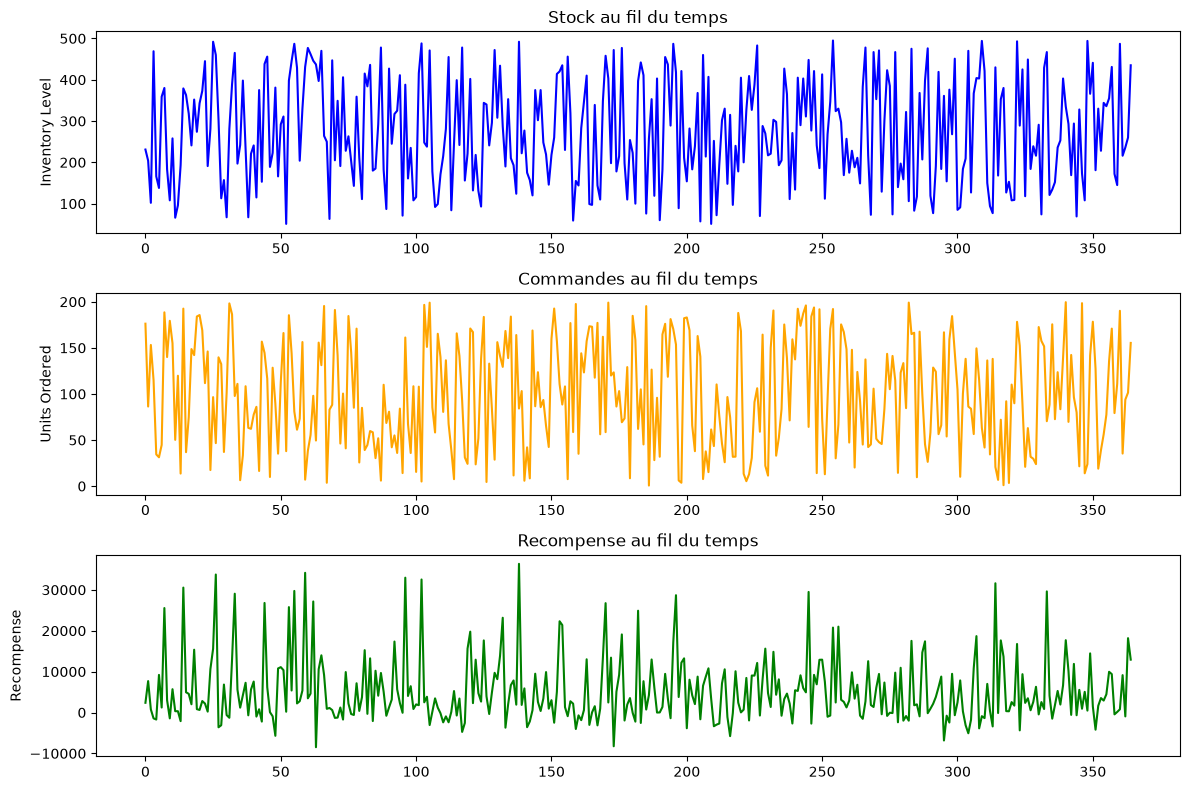

In [64]:
obs, _ = env.reset()
stocks      = []
commandes   = []
recompenses = []

for jour in range(365):
    action = env.action_space.sample()
    stocks.append(obs[0])
    commandes.append(float(action[0]))
    obs, recompense, termine, _, _ = env.step(action)
    recompenses.append(recompense)
    if termine:
        break

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(stocks, color='blue')
axes[0].set_title('Stock au fil du temps')
axes[0].set_ylabel('Inventory Level')

axes[1].plot(commandes, color='orange')
axes[1].set_title('Commandes au fil du temps')
axes[1].set_ylabel('Units Ordered')

axes[2].plot(recompenses, color='green')
axes[2].set_title('Recompense au fil du temps')
axes[2].set_ylabel('Recompense')

plt.tight_layout()
plt.savefig('../results/plots/episode_test.png')
plt.show()

L'environnement InventoryEnv fonctionne correctement. Les tests confirment que reset() reinitialise correctement. 

step() calcule la recompense selon le Newsvendor Problem et l'episode se termine apres exactement 365 jours.

Avec des actions aleatoires la recompense est instable ce qui est normal. L'agent DDPG apprendra a stabiliser les commandes pour maximiser la recompense totale.

In [65]:
row1 = df.iloc[0]
row2 = df.iloc[1]

print(f"Jour 1 : Stock={row1['Inventory Level']} Vendu={row1['Units Sold']} Commande={row1['Units Ordered']}")
print(f"Jour 2 : Stock={row2['Inventory Level']}")
print(f"Stock calcule : {row1['Inventory Level'] + row1['Units Ordered'] - row1['Units Sold']}")

Jour 1 : Stock=231 Vendu=127 Commande=55
Jour 2 : Stock=204
Stock calcule : 159
